# Tarea 1.5 - Análisis de correlaciones

## 1. Carga del dataset con características relacionales

In [1]:
import pandas as pd

df = pd.read_csv("../data/cora_features_completas.csv")

df.head()

,paper_id,word_0,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,...,word_1428,word_1429,word_1430,word_1431,word_1432,centralidad_grado,centralidad_betweenness,coeficiente_clustering,comunidad_louvain,class_label
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0.001847,1.365161e-07,0.800000,34,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0.000369,0.000000e+00,0.000000,6,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0.001478,2.034748e-04,0.166667,13,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0.001108,2.746370e-05,0.000000,13,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0.000369,0.000000e+00,0.000000,38,Probabilistic_Methods


In [2]:
# Verificamos el tamaño del DataFrame para asegurarnos de que se ha cargado correctamente
df.shape

(2708, 1439)

Antes de hacer las correlaciones debemos separar las variables (columnas) por tipos. En esta sección se identifican las variables que se usarán en el análisis de correlaciones. Las métricas de centralidad y clustering se tratan como variables numéricas continuas. La comunidad detectada mediante Louvain se trata como variable categórica, ya que sus valores identifican grupos pero no representan un orden numérico. La variable class_label representa la clase real del paper y será utilizada para analizar la relación entre las métricas extraídas y la categoría temática.

Variables numéricas relacionales:
- centralidad_grado
- centralidad_betweenness
- coeficiente_clustering

Variables categóricas:
- comunidad_louvain
- class_label

Variables textuales/binarias:
- word_0, word_1, ..., word_1432

In [3]:
# Columnas relacionales numéricas
features_relacionales_numericas = [
    "centralidad_grado",
    "centralidad_betweenness",
    "coeficiente_clustering"
]

# Columnas categóricas
feature_comunidad = "comunidad_louvain"
target = "class_label"

# Columnas textuales/binarias
features_textuales = [col for col in df.columns if col.startswith("word_")]

In [4]:
print("Número de columnas textuales:", len(features_textuales))
print("Features relacionales numéricas:", features_relacionales_numericas)
print("Feature de comunidad:", feature_comunidad)
print("Variable objetivo:", target)

Número de columnas textuales: 1433
Features relacionales numéricas: ['centralidad_grado', 'centralidad_betweenness', 'coeficiente_clustering']
Feature de comunidad: comunidad_louvain
Variable objetivo: class_label


In [5]:
# Comprobamos si hay valores nulos en las columnas relevantes
columnas_relevantes = features_relacionales_numericas + [feature_comunidad, target]

df[columnas_relevantes].isnull().sum()

centralidad_grado          0
centralidad_betweenness    0
coeficiente_clustering     0
comunidad_louvain          0
class_label                0
dtype: int64

In [6]:
# Antes de correlacionar, miramos cómo son las métricas

df[features_relacionales_numericas].describe()

,centralidad_grado,centralidad_betweenness,coeficiente_clustering
count,2708.000000,2708.000000,2708.000000
mean,0.001440,0.001653,0.240673
std,0.001932,0.006941,0.322079
min,0.000369,0.000000,0.000000
25%,0.000739,0.000000,0.000000
50%,0.001108,0.000255,0.095238
75%,0.001847,0.001299,0.333333
max,0.062061,0.232488,1.000000


In [7]:
print("Distribución de clases:")
print(df[target].value_counts())

print("\nNúmero de comunidades Louvain:")
print(df[feature_comunidad].nunique())

print("\nTamaño de cada comunidad:")
print(df[feature_comunidad].value_counts().sort_index())

Distribución de clases:
class_label
Neural_Networks           818
Probabilistic_Methods     426
Genetic_Algorithms        418
Theory                    351
Case_Based                298
Reinforcement_Learning    217
Rule_Learning             180
Name: count, dtype: int64

Número de comunidades Louvain:
102

Tamaño de cada comunidad:
comunidad_louvain
0       26
1       13
2      182
3      151
4      158
      ... 
97       2
98       2
99       2
100      2
101      2
Name: count, Length: 102, dtype: int64


## 2. Correlación entre métricas relacionales numéricas

En esta sección se analizan las métricas relacionales numéricas extraidas del grafo. Con esto pretendemos conocer si algunas variables son redundantes o aportan información diferente sobre la posición estructural de cada nodo.


In [8]:
# Seleccionamos únicamente las métricas relacionales numéricas
df_rel_num = df[features_relacionales_numericas]

df_rel_num.head()

,centralidad_grado,centralidad_betweenness,coeficiente_clustering
0,0.001847,1.365161e-07,0.800000
1,0.000369,0.000000e+00,0.000000
2,0.001478,2.034748e-04,0.166667
3,0.001108,2.746370e-05,0.000000
4,0.000369,0.000000e+00,0.000000


In [9]:
# Ahora calculamos la matriz de correlación de Pearson
corr_pearson = df_rel_num.corr(method="pearson")

corr_pearson

,centralidad_grado,centralidad_betweenness,coeficiente_clustering
centralidad_grado,1.000000,0.874623,-0.035711
centralidad_betweenness,0.874623,1.000000,-0.103831
coeficiente_clustering,-0.035711,-0.103831,1.000000


In [10]:
# Y ahora la matriz de correlación de Spearman
corr_spearman = df_rel_num.corr(method="spearman")

corr_spearman

,centralidad_grado,centralidad_betweenness,coeficiente_clustering
centralidad_grado,1.000000,0.760951,0.384908
centralidad_betweenness,0.760951,1.000000,-0.052526
coeficiente_clustering,0.384908,-0.052526,1.000000


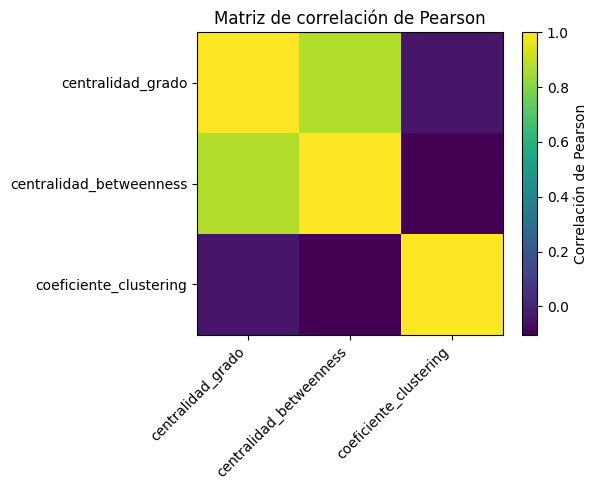

In [12]:
# Insertamos un heatmap para visualizar la matriz de correlación de Pearson

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(corr_pearson, aspect="auto")
plt.colorbar(label="Correlación de Pearson")
plt.xticks(range(len(corr_pearson.columns)), corr_pearson.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_pearson.index)), corr_pearson.index)
plt.title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.show()

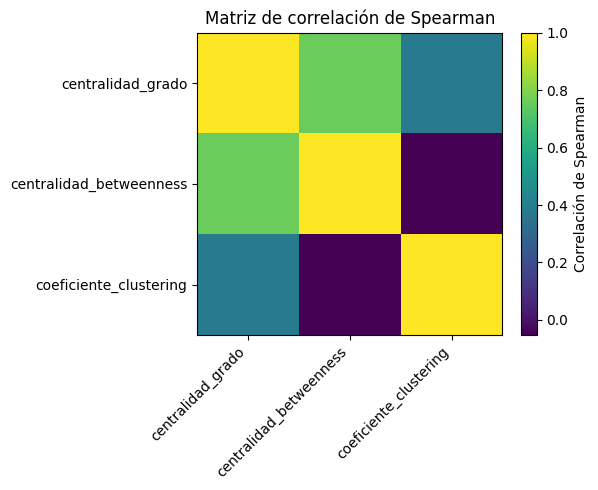

In [13]:
# Y ahora un heatmap para la matriz de correlación de Spearman

plt.figure(figsize=(6, 5))
plt.imshow(corr_spearman, aspect="auto")
plt.colorbar(label="Correlación de Spearman")
plt.xticks(range(len(corr_spearman.columns)), corr_spearman.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_spearman.index)), corr_spearman.index)
plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.show()

La matriz de correlación permite observar el grado de relación entre las métricas relacionales numéricas. En primer lugar, se compara la centralidad de grado con la centralidad de intermediación para comprobar si los nodos con más conexiones también actúan como puentes dentro del grafo. Además, se analiza el coeficiente de clustering para ver si aporta información diferente relacionada con la densidad local del vecindario de cada nodo.

A partir de los valores obtenidos, se observa que [...]

## 3. Relación entre métricas relacionales y clase

En esta sección se analiza si las métricas relacionales numéricas presentan diferencias según la clase temática de los papers. Para ello se estudia la distribución de cada métrica por clase mediante gráficos de caja y se aplica un test estadístico no paramétrico.

In [14]:
# Resumen estadístico de las métricas relacionales por clase
df.groupby(target)[features_relacionales_numericas].agg(["mean", "median", "std"])

centralidad_grado                      \
                                    mean    median       std   
class_label                                                    
Case_Based                      0.001346  0.001108  0.001011   
Genetic_Algorithms              0.001614  0.001108  0.003197   
Neural_Networks                 0.001282  0.001108  0.001678   
Probabilistic_Methods           0.001381  0.001108  0.001215   
Reinforcement_Learning          0.001752  0.001108  0.002498   
Rule_Learning                   0.001350  0.001108  0.001212   
Theory                          0.001607  0.001108  0.001625   

                       centralidad_betweenness                      \
                                          mean    median       std   
class_label                                                          
Case_Based                            0.001393  0.000344  0.003092   
Genetic_Algorithms                    0.001781  0.000127  0.012036   
Neural_Networks                       0.001605  0.000235  0.006269   
Probabilistic_Methods                 0.001818  0.000189  0.005897   
Reinforcement_Learning                0.001827  0.000265  0.006525   
Rule_Learning                         0.000774  0.000050  0.001876   
Theory                                0.001974  0.000526  0.005412   

                       coeficiente_clustering                      
                                         mean    median       std  
class_label                                                        
Case_Based                           0.215075  0.069048  0.300281  
Genetic_Algorithms                   0.288453  0.166667  0.333122  
Neural_Networks                      0.225526  0.000000  0.324464  
Probabilistic_Methods                0.265211  0.100000  0.338348  
Reinforcement_Learning               0.234421  0.100000  0.306539  
Rule_Learning                        0.274881  0.123016  0.342991  
Theory                               0.197349  0.046154  0.289159

<Figure size 1000x500 with 0 Axes>

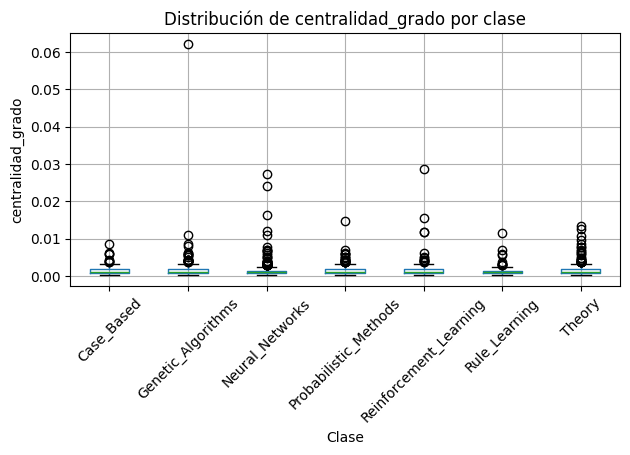

<Figure size 1000x500 with 0 Axes>

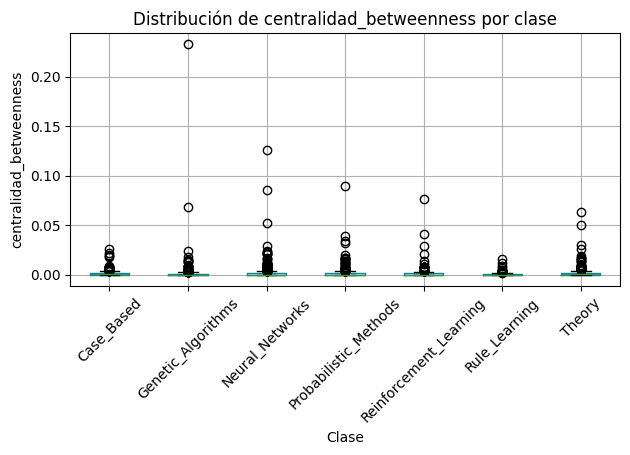

<Figure size 1000x500 with 0 Axes>

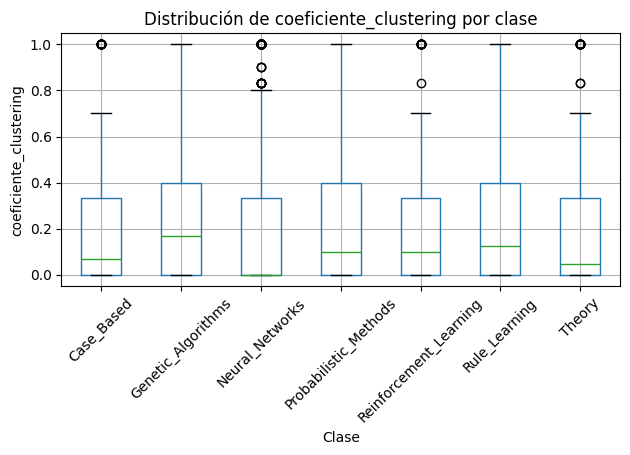

In [15]:
for feature in features_relacionales_numericas:
    plt.figure(figsize=(10, 5))
    df.boxplot(column=feature, by=target, rot=45)
    plt.title(f"Distribución de {feature} por clase")
    plt.suptitle("")
    plt.xlabel("Clase")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

In [16]:
from scipy.stats import kruskal

resultados_kruskal = []

for feature in features_relacionales_numericas:
    grupos = [
        grupo[feature].dropna().values
        for _, grupo in df.groupby(target)
    ]
    
    stat, p_value = kruskal(*grupos)
    
    resultados_kruskal.append({
        "feature": feature,
        "estadistico": stat,
        "p_value": p_value
    })

df_kruskal = pd.DataFrame(resultados_kruskal)
df_kruskal

,feature,estadistico,p_value
0,centralidad_grado,45.377880,3.936888e-08
1,centralidad_betweenness,24.208399,4.781077e-04
2,coeficiente_clustering,29.828402,4.237365e-05


Los gráficos de caja permiten comparar la distribución de cada métrica relacional entre las distintas clases del dataset. En el caso de `centralidad_grado`, se observa que [...]. Para `centralidad_betweenness`, [...]. En cuanto al `coeficiente_clustering`, [...].

El test de Kruskal-Wallis muestra que [...], ya que los valores p obtenidos son [...]. Esto sugiere que algunas métricas relacionales podrían aportar información útil para diferenciar las clases, aunque será necesario comprobarlo posteriormente mediante modelos de clasificación.

## 4. Relación entre comunidades Louvain y clase

En esta sección se analiza la relación entre la comunidad detectada mediante el algoritmo Louvain y la clase real de cada paper. Ambas variables son categóricas, por lo que no se aplica una correlación de Pearson o Spearman, sino una tabla de contingencia y un test chi-cuadrado de independencia.

In [17]:
# Tabla de contingencia: comunidades Louvain frente a clases reales
tabla_comunidad_clase = pd.crosstab(
    df[feature_comunidad],
    df[target]
)

tabla_comunidad_clase

class_label,Case_Based,Genetic_Algorithms,Neural_Networks,Probabilistic_Methods,Reinforcement_Learning,Rule_Learning,Theory
comunidad_louvain,,,,,,,
0,1,15,3,0,7,0,0
1,4,9,0,0,0,0,0
2,0,1,142,33,2,0,4
3,139,0,6,0,0,4,2
4,0,4,13,2,8,0,131
...,...,...,...,...,...,...,...
97,0,0,2,0,0,0,0
98,0,0,2,0,0,0,0
99,0,0,0,0,0,2,0


In [18]:
# Tabla normalizada por filas: proporción de clases dentro de cada comunidad
tabla_comunidad_clase_norm = pd.crosstab(
    df[feature_comunidad],
    df[target],
    normalize="index"
)

tabla_comunidad_clase_norm

class_label,Case_Based,Genetic_Algorithms,Neural_Networks,Probabilistic_Methods,Reinforcement_Learning,Rule_Learning,Theory
comunidad_louvain,,,,,,,
0,0.038462,0.576923,0.115385,0.000000,0.269231,0.00000,0.000000
1,0.307692,0.692308,0.000000,0.000000,0.000000,0.00000,0.000000
2,0.000000,0.005495,0.780220,0.181319,0.010989,0.00000,0.021978
3,0.920530,0.000000,0.039735,0.000000,0.000000,0.02649,0.013245
4,0.000000,0.025316,0.082278,0.012658,0.050633,0.00000,0.829114
...,...,...,...,...,...,...,...
97,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000
98,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000
99,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000


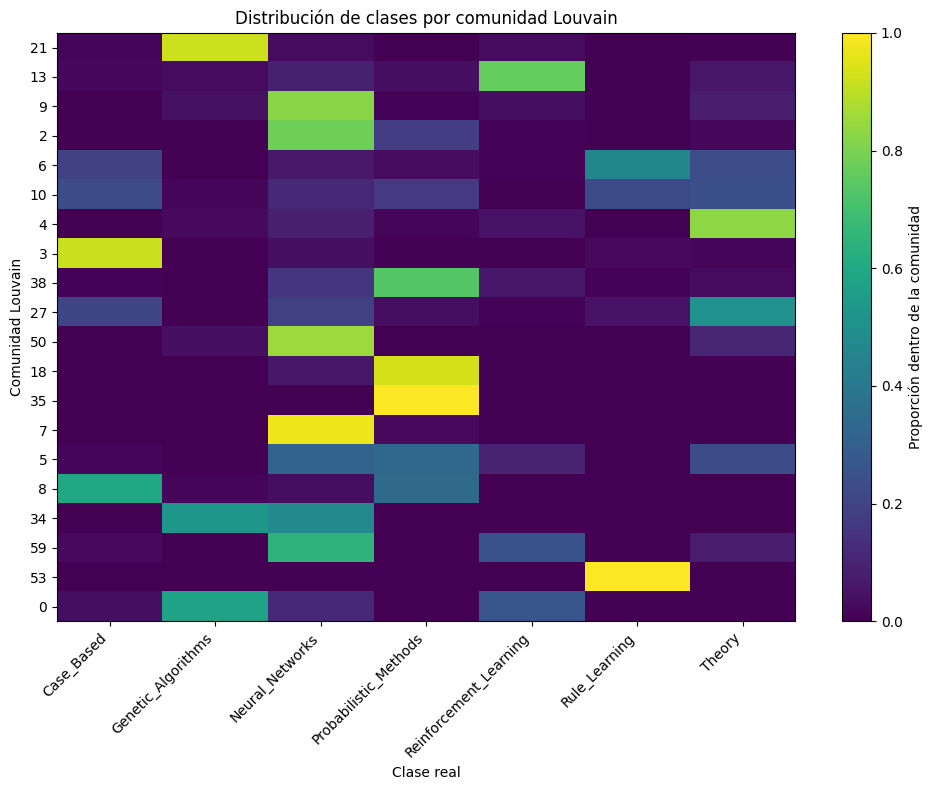

In [19]:
# Seleccionamos las comunidades con más nodos para que el gráfico sea legible
top_comunidades = df[feature_comunidad].value_counts().head(20).index

tabla_top = tabla_comunidad_clase_norm.loc[top_comunidades]

plt.figure(figsize=(10, 8))
plt.imshow(tabla_top, aspect="auto")
plt.colorbar(label="Proporción dentro de la comunidad")

plt.xticks(
    range(len(tabla_top.columns)),
    tabla_top.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(tabla_top.index)),
    tabla_top.index
)

plt.xlabel("Clase real")
plt.ylabel("Comunidad Louvain")
plt.title("Distribución de clases por comunidad Louvain")
plt.tight_layout()
plt.show()

In [20]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(tabla_comunidad_clase)

print("Estadístico chi-cuadrado:", chi2)
print("p-value:", p_value)
print("Grados de libertad:", dof)

Estadístico chi-cuadrado: 9375.286390259513
p-value: 0.0
Grados de libertad: 606


In [21]:
import numpy as np

def cramers_v(tabla):
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.to_numpy().sum()
    filas, columnas = tabla.shape
    
    return np.sqrt(chi2 / (n * (min(filas, columnas) - 1)))

cramers_v_valor = cramers_v(tabla_comunidad_clase)

print("Cramér's V:", cramers_v_valor)

Cramér's V: 0.7596128736177717


La tabla de contingencia permite analizar cómo se distribuyen las clases reales de los papers dentro de las comunidades detectadas por Louvain. En el heatmap se observa que [...].

El test chi-cuadrado obtiene un p-value de [...], por lo que [...]. Además, el valor de Cramér's V es [...], lo que indica una asociación [...].

Estos resultados sugieren que la variable `comunidad_louvain` puede aportar información útil para la clasificación, ya que las comunidades detectadas a partir de la estructura del grafo no parecen ser completamente independientes de las clases reales.

## 5. Conclusión sobre la selección de características

En esta sección se resumen los resultados obtenidos en el análisis de correlaciones y asociación entre variables. El objetivo es justificar qué características relacionales se conservarán para la fase posterior de modelado.

In [22]:
# Resumen de correlaciones entre métricas numéricas
pares_correlacion = []

for i, feature_1 in enumerate(features_relacionales_numericas):
    for feature_2 in features_relacionales_numericas[i + 1:]:
        pares_correlacion.append({
            "feature_1": feature_1,
            "feature_2": feature_2,
            "pearson": corr_pearson.loc[feature_1, feature_2],
            "spearman": corr_spearman.loc[feature_1, feature_2]
        })

df_resumen_correlaciones = pd.DataFrame(pares_correlacion)
df_resumen_correlaciones

,feature_1,feature_2,pearson,spearman
0,centralidad_grado,centralidad_betweenness,0.874623,0.760951
1,centralidad_grado,coeficiente_clustering,-0.035711,0.384908
2,centralidad_betweenness,coeficiente_clustering,-0.103831,-0.052526


## 5. Conclusión sobre la selección de características

En esta sección se resumen los resultados obtenidos en el análisis de correlaciones y asociación entre variables. El objetivo es justificar qué características relacionales se conservarán para la fase posterior de modelado.

In [23]:
# Ordenamos los resultados del test Kruskal-Wallis
df_kruskal.sort_values("p_value")

,feature,estadistico,p_value
0,centralidad_grado,45.377880,3.936888e-08
2,coeficiente_clustering,29.828402,4.237365e-05
1,centralidad_betweenness,24.208399,4.781077e-04


In [24]:
resumen_comunidad = pd.DataFrame([{
    "variable_1": feature_comunidad,
    "variable_2": target,
    "chi2": chi2,
    "p_value": p_value,
    "cramers_v": cramers_v_valor
}])

resumen_comunidad

,variable_1,variable_2,chi2,p_value,cramers_v
0,comunidad_louvain,class_label,9375.28639,0.0,0.759613


In [25]:
features_relacionales_finales = [
    "centralidad_grado",
    "centralidad_betweenness",
    "coeficiente_clustering",
    "comunidad_louvain"
]

features_relacionales_finales

['centralidad_grado',
 'centralidad_betweenness',
 'coeficiente_clustering',
 'comunidad_louvain']

A partir del análisis realizado, se decide conservar inicialmente todas las características relacionales extraídas: `centralidad_grado`, `centralidad_betweenness`, `coeficiente_clustering` y `comunidad_louvain`.

Aunque algunas métricas puedan presentar cierta correlación entre sí, cada una representa una propiedad estructural diferente del grafo: conectividad directa, papel como nodo puente, densidad local del vecindario y pertenencia a comunidades. Por tanto, se considera razonable mantenerlas para la fase de modelado y comprobar posteriormente su utilidad real mediante modelos de clasificación y validación.

In [26]:
from pathlib import Path

output_dir = Path("../results/tarea_1_5")
output_dir.mkdir(parents=True, exist_ok=True)

df_resumen_correlaciones.to_csv(output_dir / "correlaciones_metricas_relacionales.csv", index=False)
df_kruskal.to_csv(output_dir / "kruskal_metricas_por_clase.csv", index=False)
resumen_comunidad.to_csv(output_dir / "asociacion_comunidad_clase.csv", index=False)

print("Resultados guardados en:", output_dir)

Resultados guardados en: ..\results\tarea_1_5


## Conclusión final de la Tarea 1.5

El análisis de correlaciones entre métricas relacionales muestra que [...]. Esto indica que las métricas calculadas capturan información estructural [...].

El análisis por clase mediante gráficos de caja y el test de Kruskal-Wallis muestra que [...]. Por tanto, algunas métricas relacionales presentan diferencias según la categoría temática del paper.

Por otro lado, el análisis entre `comunidad_louvain` y `class_label` muestra que [...]. El test chi-cuadrado obtiene un p-value de [...] y Cramér's V toma un valor de [...], lo que sugiere una asociación [...] entre las comunidades detectadas y las clases reales.

En consecuencia, se decide conservar inicialmente las cuatro características relacionales generadas en la Tarea 1.4 para la fase posterior de modelado. La utilidad real de estas variables se evaluará comparando modelos entrenados con distintas combinaciones de características.